# Harsh Driving Event Detection — Random Forest v2

This notebook implements the **Random Forest v2** pipeline for real-time harsh driving detection.

### Key Architectural Updates & Features:
1. **Magnetometer Removal**: Excluded `mag_x`, `mag_y`, `mag_z`, and `mag_mag` to eliminate domain gap between real-world phone sensors ($\mu T$) and CARLA simulation.
2. **Base Channels Kept (6)**: `acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`.
3. **New S-Curve & Net Yaw Features**:
   - `net_yaw_cumsum20`: Rolling 20-sample sum of `gyro_z` (distinguishes continuous $90^\circ$ turns vs balanced lane changes).
   - `biphasic_yaw_signature`: `rolling_min(gyro_z, 20) * rolling_max(gyro_z, 20)` (captures steering left-then-right negative product signature).
   - `acc_y_jerk_std5`: Rolling standard deviation of lateral jerk (`acc_y.diff()`), capturing lateral snap.
4. **Window Feature Extraction**: 28 statistical summary features extracted per channel across 43 derived feature channels (1,200+ features/window).
5. **Grouped Split Manifest Alignment**: Strict non-overlapping split based on `artifacts/split_manifest.csv`.
6. **Class Balancing & Hyperparameter Tuning**: SMOTE / RandomOverSampler with Optuna tuning for `RandomForestClassifier`.
7. **Model Bundle Export**: Exported `.joblib` bundle compatible with CARLA real-time detector script.



In [1]:
# ── Cell 1: Install & Verify Dependencies ────────────────────────────────────
import sys
import pkg_resources

required = {"scikit-learn", "optuna", "imbalanced-learn", "joblib", "pandas", "numpy", "matplotlib", "seaborn", "scipy"}
installed = {pkg.key for pkg in pkg_resources.working_set}
missing = required - installed

if missing:
    print(f"Missing packages: {missing}")
else:
    print("✓ All dependencies installed and ready.")



✓ All dependencies installed and ready.


In [2]:
# ── Cell 2: Imports & Configuration ──────────────────────────────────────────
from __future__ import annotations

import os
import sys
import random
import warnings
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = ROOT / "dataset"
SRC_DIR     = ROOT / "src"
ARTIFACTS_DIR = ROOT / "notebooks" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from harsh_event_model import load_row_labeled_data

# Base IMU columns without magnetometer
IMU_COLUMNS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

# ── Window Parameters ─────────────────────────────────────────────────────────
WINDOW_SIZE     = 25
STEP_SIZE       = 5
MIN_EVENT_RATIO = 0.30   # fraction of window that must be non-safe to label as event

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"ROOT          : {ROOT}")
print(f"DATASET_DIR   : {DATASET_DIR}  (exists={DATASET_DIR.exists()})")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"IMU columns (No Mag) : {IMU_COLUMNS}")



ROOT          : /home/pw26_rr_09/pw26_rr_07/baseModel
DATASET_DIR   : /home/pw26_rr_09/pw26_rr_07/baseModel/dataset  (exists=True)
ARTIFACTS_DIR : /home/pw26_rr_09/pw26_rr_07/baseModel/notebooks/artifacts
IMU columns (No Mag) : ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']


In [3]:
# ── Cell 3: Data Loading & Derived Row-Level Feature Engineering ──────────────
raw_df = load_row_labeled_data(DATASET_DIR)

print(f"Total rows: {len(raw_df):,}")
print(f"Source files: {raw_df['source_file'].nunique()}")
print(f"\nEvent label distribution:")
print(raw_df["event_label"].value_counts())

# ── Median-filter smoothing per file ──────────────────────────────────────────
clean_df = raw_df.copy()
for col in IMU_COLUMNS:
    clean_df[col] = (
        clean_df.groupby("source_file")[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

# ── S-Curve & Net Yaw Feature Engineering ─────────────────────────────────────
def add_engineered_features(df):
    df = df.copy()

    # Magnitudes (acc + gyro only)
    df['acc_mag']  = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

    # Jerk
    for axis in ['acc_x', 'acc_y', 'acc_z']:
        df[f'{axis}_jerk'] = df.groupby('source_file')[axis].transform(
            lambda s: s.diff().fillna(0.0)
        )

    # Lateral / longitudinal ratios and energy
    df['lat_long_ratio']        = df['acc_y'].abs() / (df['acc_x'].abs() + 1e-6)
    df['acc_x_abs']             = df['acc_x'].abs()
    df['acc_y_abs']             = df['acc_y'].abs()
    df['gyro_z_abs']            = df['gyro_z'].abs()
    df['acc_lat_energy']        = df['acc_y'] ** 2
    df['acc_long_energy']       = df['acc_x'] ** 2
    df['gyro_yaw_energy']       = df['gyro_z'] ** 2
    df['lat_long_energy_ratio'] = df['acc_y_abs'] / (df['acc_x_abs'] + 1e-6)
    df['turn_vs_lateral']       = df['gyro_z_abs'] / (df['acc_y_abs'] + 1e-6)
    df['yaw_acc_corr']          = df['gyro_z'] * df['acc_y']

    # Differentials
    df['gyro_z_diff'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.diff().fillna(0.0)
    )
    df['acc_y_diff'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.diff().fillna(0.0)
    )

    # Rolling statistics
    for col in ['gyro_z', 'acc_y', 'gyro_x', 'gyro_y']:
        df[f'{col}_roll_std5'] = df.groupby('source_file')[col].transform(
            lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
        )
    df['acc_y_roll_mean5'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )

    # Sign change (oscillation indicator)
    df['gyro_z_sign_change'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: (s.shift(1) * s < 0).astype(int).fillna(0)
    )

    # Roll / pitch features
    df['gyro_x_abs']          = df['gyro_x'].abs()
    df['gyro_y_abs']          = df['gyro_y'].abs()
    df['gyro_x_energy']       = df['gyro_x'] ** 2
    df['gyro_y_energy']       = df['gyro_y'] ** 2
    df['gyro_roll_pitch_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2)
    df['gyro_total_mag']      = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    df['yaw_vs_roll_pitch']   = df['gyro_z_abs'] / (df['gyro_roll_pitch_mag'] + 1e-6)

    # Sustained-yaw peak features
    df['gyro_z_roll_max5']    = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(5,  min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_max10']   = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(10, min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_energy5'] = df.groupby('source_file')['gyro_yaw_energy'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )
    df['yaw_dominance']       = df['gyro_z_abs'] / (df['gyro_total_mag'] + 1e-6)

    # ── S-CURVE & NET YAW FEATURES FOR LANE CHANGE DISCRIMINATION ─────────────
    df['net_yaw_cumsum20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).sum().fillna(0.0)
    )
    df['gyro_z_roll_min20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).min().fillna(0.0)
    )
    df['gyro_z_roll_max20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).max().fillna(0.0)
    )
    df['biphasic_yaw_signature'] = df['gyro_z_roll_min20'] * df['gyro_z_roll_max20']
    df['acc_y_jerk_std5'] = df.groupby('source_file')['acc_y_jerk'].transform(
        lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
    )

    return df

clean_df = add_engineered_features(clean_df)

FEATURE_CHANNELS = IMU_COLUMNS + [
    'acc_mag', 'gyro_mag',
    'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk',
    'lat_long_ratio',
    'acc_x_abs', 'acc_y_abs', 'gyro_z_abs',
    'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy',
    'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr',
    'gyro_z_diff', 'acc_y_diff',
    'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5',
    'gyro_z_sign_change',
    'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy',
    'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch',
    'gyro_x_roll_std5', 'gyro_y_roll_std5',
    'gyro_z_roll_max5', 'gyro_z_roll_max10',
    'gyro_z_roll_energy5', 'yaw_dominance',
    'net_yaw_cumsum20', 'biphasic_yaw_signature', 'acc_y_jerk_std5',
]

print(f"\nFeature channels count ({len(FEATURE_CHANNELS)}): {FEATURE_CHANNELS}")



Total rows: 32,043
Source files: 53

Event label distribution:
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: event_label, dtype: int64

Feature channels count (43): ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_mag', 'gyro_mag', 'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'lat_long_ratio', 'acc_x_abs', 'acc_y_abs', 'gyro_z_abs', 'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy', 'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr', 'gyro_z_diff', 'acc_y_diff', 'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5', 'gyro_z_sign_change', 'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy', 'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch', 'gyro_x_roll_std5', 'gyro_y_roll_std5', 'gyro_z_roll_max5', 'gyro_z_roll_max10', 'gyro_z_roll_energy5', 'yaw_domi

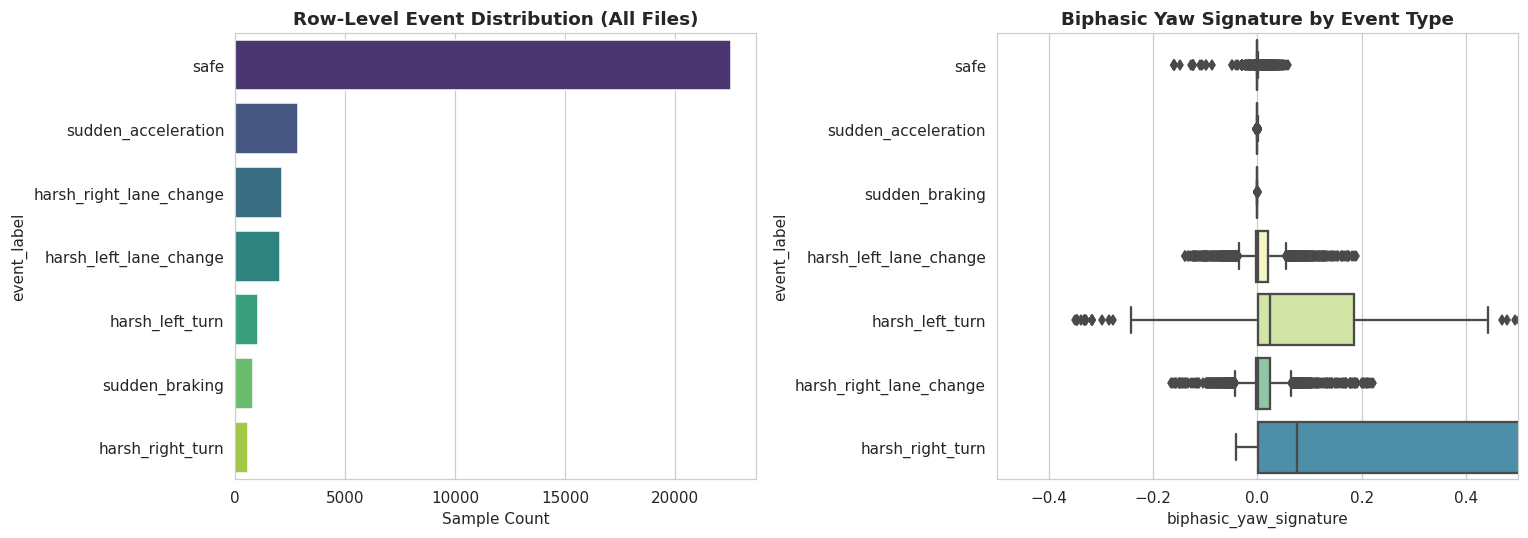

In [4]:
# ── Cell 4: Exploratory Data Analysis ───────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
sns.countplot(
    data=clean_df,
    y="event_label",
    order=clean_df["event_label"].value_counts().index,
    palette="viridis",
    ax=ax[0]
)
ax[0].set_title("Row-Level Event Distribution (All Files)", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Sample Count")

# Yaw vs S-Curve distribution boxplot
sns.boxplot(
    data=clean_df,
    x="biphasic_yaw_signature",
    y="event_label",
    palette="Spectral",
    ax=ax[1]
)
ax[1].set_title("Biphasic Yaw Signature by Event Type", fontsize=12, fontweight="bold")
ax[1].set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()



In [5]:
# ── Cell 5: Enhanced Window Feature Extraction (28 stats per channel) ────────

def extract_window_features(window_2d: np.ndarray, col_names: list) -> dict:
    """Extract 28 statistical features per channel from a sliding window."""
    feats = {}

    for i, col in enumerate(col_names):
        x = window_2d[:, i].astype(np.float64)
        dx = np.diff(x)
        abs_x = np.abs(x)
        pos = x[x > 0]
        neg = x[x < 0]

        feats[f"{col}_mean"]         = np.mean(x)
        feats[f"{col}_std"]          = np.std(x)
        feats[f"{col}_min"]          = np.min(x)
        feats[f"{col}_max"]          = np.max(x)
        feats[f"{col}_range"]        = feats[f"{col}_max"] - feats[f"{col}_min"]
        feats[f"{col}_q25"]          = np.percentile(x, 25)
        feats[f"{col}_q75"]          = np.percentile(x, 75)
        feats[f"{col}_iqr"]          = feats[f"{col}_q75"] - feats[f"{col}_q25"]
        feats[f"{col}_rms"]          = np.sqrt(np.mean(x**2))
        feats[f"{col}_energy"]       = np.sum(x**2)
        feats[f"{col}_abs_mean"]     = np.mean(abs_x)
        feats[f"{col}_abs_std"]      = np.std(abs_x)
        feats[f"{col}_abs_max"]      = np.max(abs_x)

        # Higher moments
        std_val = feats[f"{col}_std"]
        feats[f"{col}_skew"]     = float(skew(x)) if std_val > 1e-6 else 0.0
        feats[f"{col}_kurtosis"] = float(kurtosis(x)) if std_val > 1e-6 else 0.0

        # Dynamics (first / last / delta)
        feats[f"{col}_delta"] = x[-1] - x[0]
        feats[f"{col}_first"] = x[0]
        feats[f"{col}_last"]  = x[-1]

        # Pos / Neg split
        feats[f"{col}_pos_ratio"] = len(pos) / len(x)
        feats[f"{col}_neg_ratio"] = len(neg) / len(x)
        feats[f"{col}_pos_mean"]  = np.mean(pos) if len(pos) > 0 else 0.0
        feats[f"{col}_neg_mean"]  = np.mean(neg) if len(neg) > 0 else 0.0

        # Differentials
        feats[f"{col}_diff_mean"]    = np.mean(dx) if len(dx) > 0 else 0.0
        feats[f"{col}_diff_std"]     = np.std(dx) if len(dx) > 0 else 0.0
        feats[f"{col}_diff_abs_max"] = np.max(np.abs(dx)) if len(dx) > 0 else 0.0
        dstd = feats[f"{col}_diff_std"]
        feats[f"{col}_diff_skew"]    = float(skew(dx)) if dstd > 1e-6 else 0.0
        feats[f"{col}_diff_kurt"]    = float(kurtosis(dx)) if dstd > 1e-6 else 0.0

        # Zero-crossings
        feats[f"{col}_zcr"] = np.sum(np.diff(np.signbit(x))) / (len(x) - 1)

    # ── Cross-sensor interaction features ────────────────────────────────────
    acc_x_idx  = col_names.index('acc_x')
    acc_y_idx  = col_names.index('acc_y')
    gyro_z_idx = col_names.index('gyro_z')

    ax_win = window_2d[:, acc_x_idx]
    ay_win = window_2d[:, acc_y_idx]
    gz_win = window_2d[:, gyro_z_idx]

    # Cross-correlations
    std_ax = np.std(ax_win)
    std_ay = np.std(ay_win)
    std_gz = np.std(gz_win)

    feats['cross_corr_accx_gyroz'] = (
        np.mean((ax_win - np.mean(ax_win)) * (gz_win - np.mean(gz_win))) / (std_ax * std_gz + 1e-6)
    )
    feats['cross_corr_accy_gyroz'] = (
        np.mean((ay_win - np.mean(ay_win)) * (gz_win - np.mean(gz_win))) / (std_ay * std_gz + 1e-6)
    )

    # Peak counts
    peaks_ax, _ = find_peaks(np.abs(ax_win), height=np.mean(np.abs(ax_win)) + np.std(ax_win))
    peaks_gz, _ = find_peaks(np.abs(gz_win), height=np.mean(np.abs(gz_win)) + np.std(gz_win))
    feats['peak_count_accx']  = len(peaks_ax)
    feats['peak_count_gyroz'] = len(peaks_gz)

    # Magnitude peaks
    if 'acc_mag' in col_names:
        amag_idx = col_names.index('acc_mag')
        amag_win = window_2d[:, amag_idx]
        feats['acc_mag_peak'] = np.max(amag_win)
        feats['acc_mag_auc']  = np.sum(amag_win)

    return feats


def build_window_dataset(df: pd.DataFrame, feature_channels: list, window_size=25, step_size=5, min_event_ratio=0.30):
    all_feats = []
    all_labels = []
    group_rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.reset_index(drop=True)
        N = len(g)
        if N < window_size:
            continue

        arr = g[feature_channels].values
        labels = g["event_label"].values

        for start in range(0, N - window_size + 1, step_size):
            win_arr = arr[start : start + window_size]
            win_lbl = labels[start : start + window_size]

            # Majority event labeling with threshold
            non_safe = [lbl for lbl in win_lbl if lbl != "safe"]
            if len(non_safe) / window_size >= min_event_ratio:
                chosen_label = Counter(non_safe).most_common(1)[0][0]
            else:
                chosen_label = "safe"

            row_feats = extract_window_features(win_arr, feature_channels)
            all_feats.append(row_feats)
            all_labels.append(chosen_label)
            group_rows.append(source_file)

    X = pd.DataFrame(all_feats)
    y = np.array(all_labels)
    groups = np.array(group_rows)
    return X, y, groups


print("Building windowed feature dataset for Random Forest v2...")
X_all, y_all, groups_all = build_window_dataset(
    clean_df,
    FEATURE_CHANNELS,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=MIN_EVENT_RATIO,
)

print(f"\nFeature matrix shape : {X_all.shape}  ({X_all.shape[1]} features/window)")
print(f"Window count         : {len(y_all):,}")
print(f"\nWindow-level label distribution:")
print(pd.Series(y_all).value_counts())



Building windowed feature dataset for Random Forest v2...

Feature matrix shape : (6173, 1187)  (1187 features/window)
Window count         : 6,173

Window-level label distribution:
safe                       4148
sudden_acceleration         598
harsh_right_lane_change     458
harsh_left_lane_change      445
harsh_left_turn             217
sudden_braking              183
harsh_right_turn            124
dtype: int64


In [6]:
# ── Cell 6: Split Manifest Alignment ─────────────────────────────────────────
manifest_path = ROOT / 'artifacts' / 'split_manifest.csv'
if manifest_path.exists():
    split_df = pd.read_csv(manifest_path)
    train_files = set(split_df[split_df['split'] == 'train']['group_file'])
    val_files   = set(split_df[split_df['split'] == 'val']['group_file'])
    test_files  = set(split_df[split_df['split'] == 'test']['group_file'])
    print("Loaded split_manifest.csv successfully.")
    print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")
else:
    print("split_manifest.csv not found, using GroupShuffleSplit fallback.")

X_df, y_series, groups_series = X_all, y_all, groups_all

le = LabelEncoder()
label_order = ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change',
               'harsh_right_turn', 'safe', 'sudden_acceleration', 'sudden_braking']
le.fit(label_order)
y_encoded = le.transform(y_series)

if manifest_path.exists():
    train_mask = np.isin(groups_series, list(train_files))
    val_mask   = np.isin(groups_series, list(val_files))
    test_mask  = np.isin(groups_series, list(test_files))

    X_train, y_train = X_df[train_mask], y_encoded[train_mask]
    X_val,   y_val   = X_df[val_mask],   y_encoded[val_mask]
    X_test,  y_test  = X_df[test_mask],  y_encoded[test_mask]
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    train_val_idx, test_idx = next(gss.split(X_df, y_encoded, groups_series))
    X_test, y_test = X_df.iloc[test_idx], y_encoded[test_idx]
    train_val_groups = pd.Series(groups_series).iloc[train_val_idx]

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
    train_idx_rel, val_idx_rel = next(gss_val.split(X_df.iloc[train_val_idx], y_encoded[train_val_idx], train_val_groups))

    train_idx = train_val_idx[train_idx_rel]
    val_idx   = train_val_idx[val_idx_rel]

    X_train, y_train = X_df.iloc[train_idx], y_encoded[train_idx]
    X_val,   y_val   = X_df.iloc[val_idx],   y_encoded[val_idx]

print(f"Split sizes | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")



Loaded split_manifest.csv successfully.
Train files: 35 | Val files: 9 | Test files: 9
Split sizes | Train: 4102 | Val: 1116 | Test: 955


In [7]:
# ── Cell 7: Class Resampling on Training Split ──────────────────────────────
print("Before Resampling:")
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(le.classes_))))

ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("\nAfter Resampling:")
print(pd.Series(y_train_res).value_counts().rename(index=dict(enumerate(le.classes_))))
print(f"\nTraining samples: {len(X_train):,} → {len(X_train_res):,} after resampling")



Before Resampling:
safe                       2705
sudden_acceleration         429
harsh_right_lane_change     352
harsh_left_lane_change      267
harsh_left_turn             148
sudden_braking              137
harsh_right_turn             64
dtype: int64

After Resampling:
safe                       2705
sudden_acceleration        2705
sudden_braking             2705
harsh_left_lane_change     2705
harsh_left_turn            2705
harsh_right_lane_change    2705
harsh_right_turn           2705
dtype: int64

Training samples: 4,102 → 18,935 after resampling


In [8]:
# ── Cell 8: Optuna Hyperparameter Optimization for Random Forest ─────────────
def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 8, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }

    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )

    model.fit(X_train_res, y_train_res)

    preds = model.predict(X_val)
    return float(f1_score(y_val, preds, average="macro"))

print("Running Optuna study for Random Forest (15 trials)...")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=15, timeout=120)

print(f"\nBest trial macro-F1 : {study.best_value:.4f}")
print("Best Random Forest parameters:")
for k, v in study.best_params.items():
    print(f"  {k:<20}: {v}")



Running Optuna study for Random Forest (15 trials)...

Best trial macro-F1 : 0.6085
Best Random Forest parameters:
  n_estimators        : 250
  max_depth           : 11
  min_samples_split   : 2
  min_samples_leaf    : 5
  max_features        : 0.3
  criterion           : gini


In [9]:
# ── Cell 9: Final Random Forest Model Training ────────────────────────────────
best_params = study.best_params

final_rf = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

final_rf.fit(X_train_res, y_train_res)

val_preds = final_rf.predict(X_val)
val_f1 = f1_score(y_val, val_preds, average="macro")
print(f"Validation Macro F1: {val_f1:.4f}")



Validation Macro F1: 0.6085


FINAL RANDOM FOREST V2 TEST SET EVALUATION (Macro F1 = 0.6089)
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.6809    0.5000    0.5766        64
        harsh_left_turn     0.8696    0.6061    0.7143        33
harsh_right_lane_change     0.6667    0.8627    0.7521        51
       harsh_right_turn     0.5405    0.6667    0.5970        30
                   safe     0.8458    0.8820    0.8635       678
    sudden_acceleration     0.2931    0.2099    0.2446        81
         sudden_braking     0.5294    0.5000    0.5143        18

               accuracy                         0.7749       955
              macro avg     0.6323    0.6039    0.6089       955
           weighted avg     0.7636    0.7749    0.7657       955



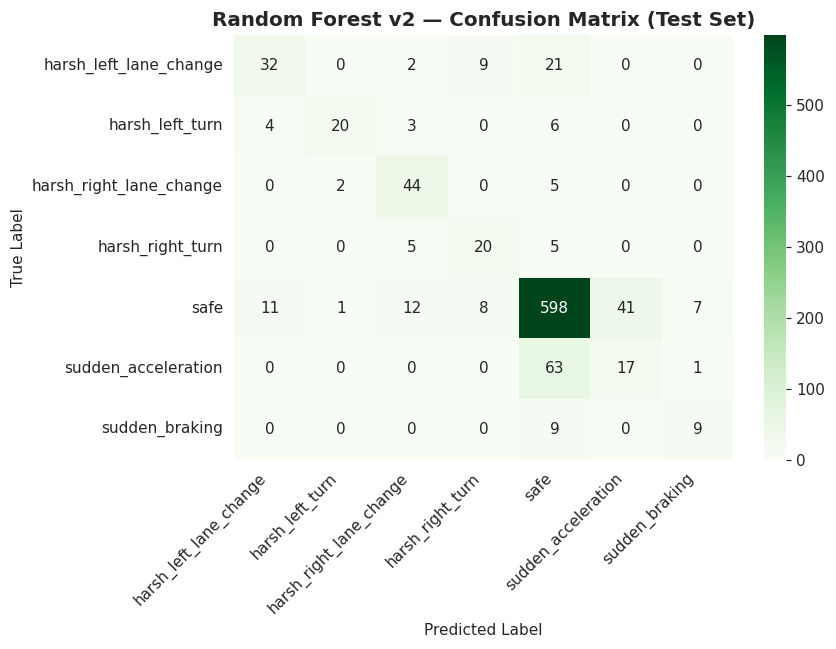

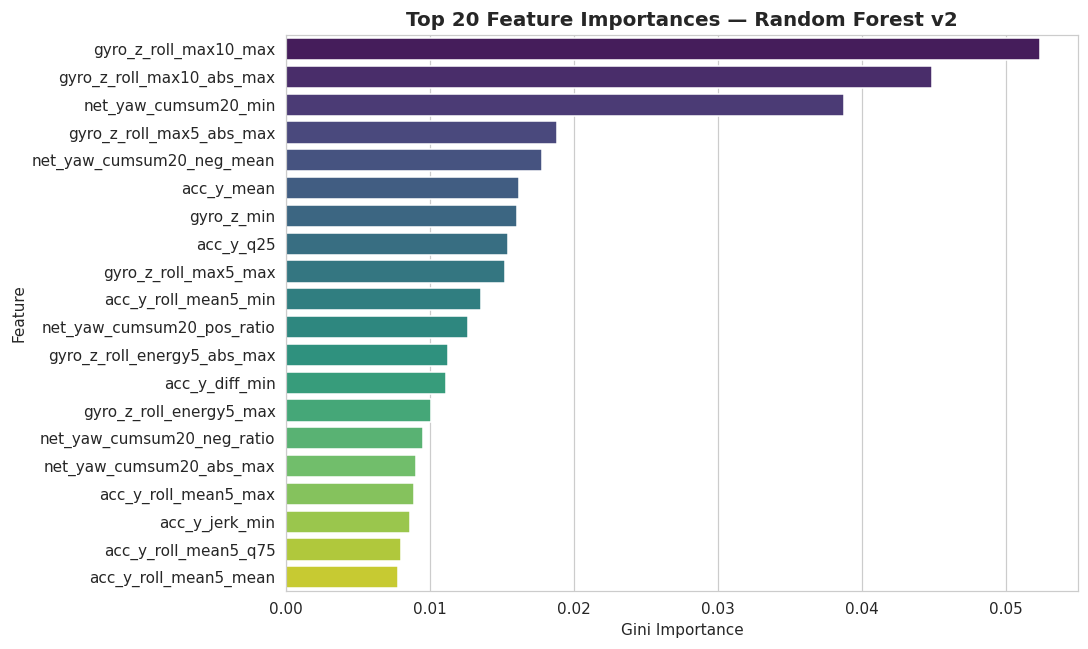

In [10]:
# ── Cell 10: Final Test Evaluation, Confusion Matrix & Feature Importances ────
test_preds = final_rf.predict(X_test)

macro_f1 = f1_score(y_test, test_preds, average="macro")
print("=" * 65)
print(f"FINAL RANDOM FOREST V2 TEST SET EVALUATION (Macro F1 = {macro_f1:.4f})")
print("=" * 65)
print(classification_report(y_test, test_preds, target_names=le.classes_, digits=4))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Random Forest v2 — Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "rf_v2_confusion_matrix.png", bbox_inches="tight")
plt.show()

# Top 20 Feature Importances Plot
importances = final_rf.feature_importances_
feature_names = X_train.columns
top_indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[top_indices],
    y=feature_names[top_indices],
    palette="viridis"
)
plt.title("Top 20 Feature Importances — Random Forest v2", fontsize=13, fontweight="bold")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "rf_v2_feature_importances.png", bbox_inches="tight")
plt.show()



In [11]:
# ── Cell 11: Export Joblib Model Bundle ──────────────────────────────────────
bundle = {
    "model": final_rf,
    "label_encoder": le,
    "feature_names": list(X_train.columns),
    "feature_columns": list(X_train.columns),
    "imu_columns": IMU_COLUMNS,
    "feature_channels": FEATURE_CHANNELS,
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "min_event_ratio": MIN_EVENT_RATIO,
    "macro_f1": macro_f1,
    "classes": list(le.classes_),
}

# Save in notebooks/artifacts and artifacts root
bundle_path_nb = ARTIFACTS_DIR / "harsh_event_rf_v2.joblib"
bundle_path_root = ROOT / "artifacts" / "harsh_event_rf_v2.joblib"

joblib.dump(bundle, bundle_path_nb)
joblib.dump(bundle, bundle_path_root)

print(f"✓ Saved Random Forest model bundle to:")
print(f"  Notebook Artifacts : {bundle_path_nb}")
print(f"  Root Artifacts     : {bundle_path_root}")



✓ Saved Random Forest model bundle to:
  Notebook Artifacts : /home/pw26_rr_09/pw26_rr_07/baseModel/notebooks/artifacts/harsh_event_rf_v2.joblib
  Root Artifacts     : /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/harsh_event_rf_v2.joblib


### CARLA Real-Time Detector Guide

To run real-time inference with this **Random Forest v2** model in CARLA:

##### Terminal 3
```bash
export PYTHONPATH=$PYTHONPATH:/home/nikhil/Downloads/CARLA_0.9.13/PythonAPI/carla/dist/carla-0.9.13-py3.7-linux-x86_64.egg

python3 src/run_carla_realtime.py \
  --model-path notebooks/artifacts/harsh_event_rf_v2.joblib \
  --heuristic \
  --print-safe \
  --min-confidence 0.40 \
  --consecutive-hits 2 \
  --sensor-tick 0.05
```

